### RC: Sinusoidal UV-A Photostimulation Readout Analysis

---

### Experimental Setup
| Component | Description |
|---|---|
| **Biophysical Reservoir** | Active continuous culture of *Saccharomyces cerevisiae* in Pioreactor |
| **Input Signal $u(t)$** | Sinusoidal UV-A LED intensity (`0% -> 5% -> 25% -> 45% -> 25% -> 5% -> 0%`, 30 min/step) |
| **Reservoir State Matrix $\mathbf{X}$** | 16 sensory dimensions (OD × 3 + AS7341 Spectrometer × 8 + nOD + Growth Rate + CO₂/Temp/RH) |
| **Readout Layer** | Ridge Regression ($L_2$ regularized) with Leave-One-Out (LOO) Cross-Validation |

---


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# High-res plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

CYCLE_MIN = 30.0
ALPHAS = np.logspace(-4, 6, 100)
print(f"Imports OK. Configured for {CYCLE_MIN}-minute cycle intervals.")

Imports OK. Configured for 30.0-minute cycle intervals.


### Section 1 — Load and Inspect Data

In [2]:
data_dir = r"data/sine wave encoding/UV"
if not os.path.exists(data_dir):
    data_dir = r"D:/omnibio/pioreactor/data/sine wave encoding/UV"

def load_csv(pattern):
    files = glob.glob(os.path.join(data_dir, pattern))
    if not files:
        raise FileNotFoundError(f"Could not find {pattern} in {data_dir}")
    df = pd.read_csv(files[0])
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    return df.sort_values('timestamp')

df_led = load_csv("led_change_events-*.csv")
df_co2 = load_csv("co2_readings-*.csv")
df_growth = load_csv("growth_rates-*.csv")
df_od = load_csv("od_readings-*.csv")
df_od_filt = load_csv("od_readings_filtered-*.csv")
df_spec = load_csv("as7341_spectrum_readings-*.csv")

t0 = df_led['timestamp'].min()
total_cycles = len(df_led)
t_end = t0 + pd.Timedelta(minutes=total_cycles * CYCLE_MIN)
u = df_led['intensity'].values

print("=== FILE SUMMARY ===")
print(f"UV LED events : {len(df_led):>6} rows | Intensities: {sorted(df_led['intensity'].unique())}")
print(f"Spectrometer  : {len(df_spec):>6} rows | Bands: {sorted(df_spec['band'].unique())}")
print(f"OD readings   : {len(df_od):>6} rows | Angles: {sorted(df_od['angle'].unique())}")
print(f"CO2 readings  : {len(df_co2):>6} rows")
print(f"Growth rates  : {len(df_growth):>6} rows")
print(f"Filtered OD   : {len(df_od_filt):>6} rows")
print(f"\nTimeline: {t0} -> {t_end} ({total_cycles * CYCLE_MIN / 60:.2f} hours, {total_cycles} cycles)")

=== FILE SUMMARY ===
UV LED events :     57 rows | Intensities: [0.0, 5.0, 25.0, 45.0]
Spectrometer  : 178560 rows | Bands: [415, 445, 480, 515, 555, 590, 630, 680]
OD readings   :  66960 rows | Angles: [45, 90, 135]
CO2 readings  :   3719 rows
Growth rates  :  21721 rows
Filtered OD   :  21721 rows

Timeline: 2026-08-18 12:05:11.980000+00:00 -> 2026-08-19 16:35:11.980000+00:00 (28.50 hours, 57 cycles)


### Section 2: 7-Subplot Multi-Panel with Dynamic UV Intensity Shading

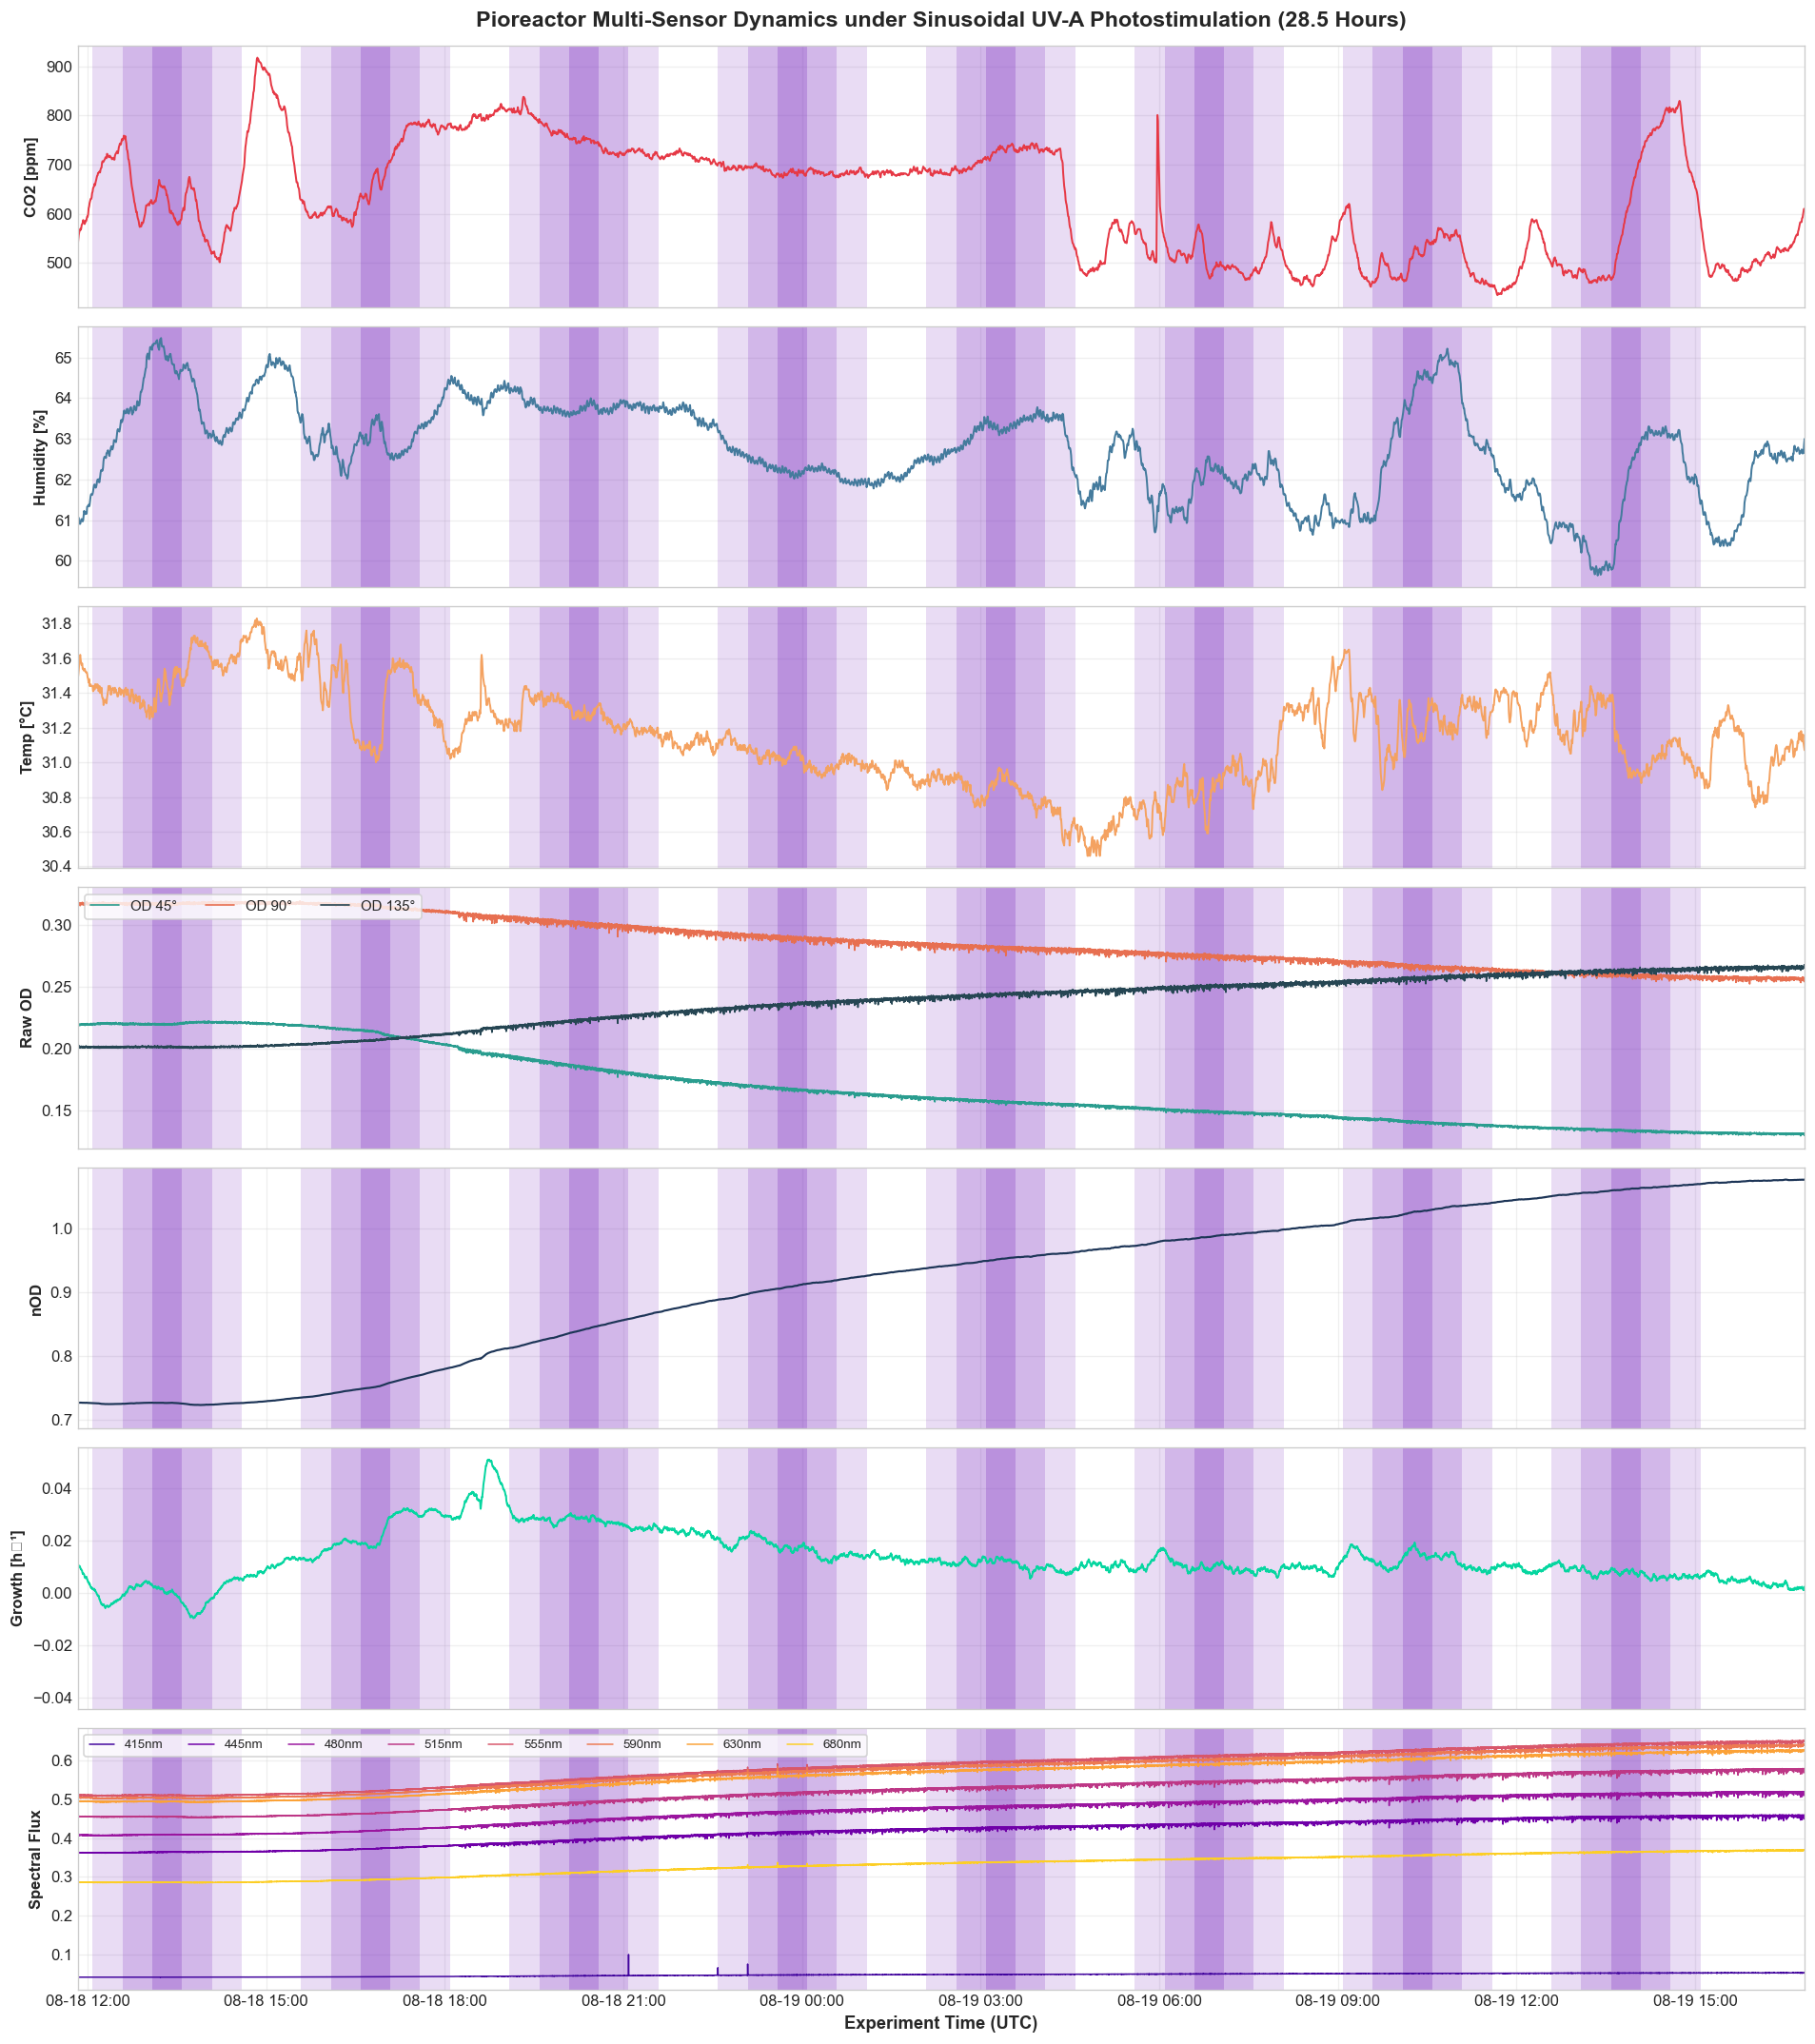

In [3]:
# Pivot OD and Spectrometer readings
df_od['dt_sec'] = df_od['timestamp'].dt.floor('s')
df_od_piv = df_od.pivot_table(index='dt_sec', columns='angle', values='od_reading', aggfunc='mean')
df_od_piv.columns = [f'OD_{col}' for col in df_od_piv.columns]

df_spec['dt_sec'] = df_spec['timestamp'].dt.floor('s')
df_spec_piv = df_spec.pivot_table(index='dt_sec', columns='band', values='reading', aggfunc='mean')
df_spec_piv.columns = [f'nm_{col}' for col in df_spec_piv.columns]

# Build UV interval spans for background shading
uv_intervals = []
led_rows = df_led.sort_values('timestamp').reset_index(drop=True)
for i in range(len(led_rows)):
    t_curr = led_rows.loc[i, 'timestamp']
    intensity = led_rows.loc[i, 'intensity']
    t_nxt = led_rows.loc[i + 1, 'timestamp'] if i < len(led_rows) - 1 else t_end
    uv_intervals.append((t_curr, t_nxt, intensity))

def add_uv_shading(ax):
    for (t_a, t_b, intensity) in uv_intervals:
        if intensity > 0:
            alpha_val = 0.12 + (intensity / 45.0) * 0.40
            ax.axvspan(t_a, t_b, color='#7b2cbf', alpha=alpha_val, lw=0)

fig, axes = plt.subplots(7, 1, figsize=(16, 18), sharex=True)

# 1. CO2
axes[0].plot(df_co2['timestamp'], df_co2['co2_reading_ppm'], color='#e63946', lw=1.2)
axes[0].set_ylabel('CO2 [ppm]', fontweight='bold')
axes[0].set_title('Pioreactor Multi-Sensor Dynamics under Sinusoidal UV-A Photostimulation (28.5 Hours)', fontsize=14, fontweight='bold', pad=12)

# 2. Relative Humidity
axes[1].plot(df_co2['timestamp'], df_co2['relative_humidity'], color='#457b9d', lw=1.2)
axes[1].set_ylabel('Humidity [%]', fontweight='bold')

# 3. Temperature
axes[2].plot(df_co2['timestamp'], df_co2['temperature_c'], color='#f4a261', lw=1.2)
axes[2].set_ylabel('Temp [°C]', fontweight='bold')

# 4. Optical Density (3 angles)
axes[3].plot(df_od_piv.index, df_od_piv['OD_45'], color='#2a9d8f', lw=1.0, label='OD 45°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_90'], color='#e76f51', lw=1.0, label='OD 90°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_135'], color='#264653', lw=1.0, label='OD 135°')
axes[3].set_ylabel('Raw OD', fontweight='bold')
axes[3].legend(loc='upper left', ncol=3, frameon=True, fontsize=9)

# 5. Normalized OD
axes[4].plot(df_od_filt['timestamp'], df_od_filt['normalized_od_reading'], color='#1d3557', lw=1.3)
axes[4].set_ylabel('nOD', fontweight='bold')

# 6. Growth Rate
axes[5].plot(df_growth['timestamp'], df_growth['rate'], color='#06d6a0', lw=1.2)
axes[5].set_ylabel('Growth [h⁻¹]', fontweight='bold')

# 7. Spectrometer 8 bands
spec_colors = cm.plasma(np.linspace(0.1, 0.9, 8))
for idx, band in enumerate([415, 445, 480, 515, 555, 590, 630, 680]):
    col = f'nm_{band}'
    if col in df_spec_piv.columns:
        axes[6].plot(df_spec_piv.index, df_spec_piv[col], color=spec_colors[idx], lw=0.9, label=f'{band}nm')
axes[6].set_ylabel('Spectral Flux', fontweight='bold')
axes[6].set_xlabel('Experiment Time (UTC)', fontweight='bold', fontsize=11)
axes[6].legend(loc='upper left', ncol=8, frameon=True, fontsize=8)

for ax in axes:
    add_uv_shading(ax)
    ax.set_xlim(t0 - pd.Timedelta(minutes=15), t_end + pd.Timedelta(minutes=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Section 3: Composite Multi-Sensor Normalized Overlay

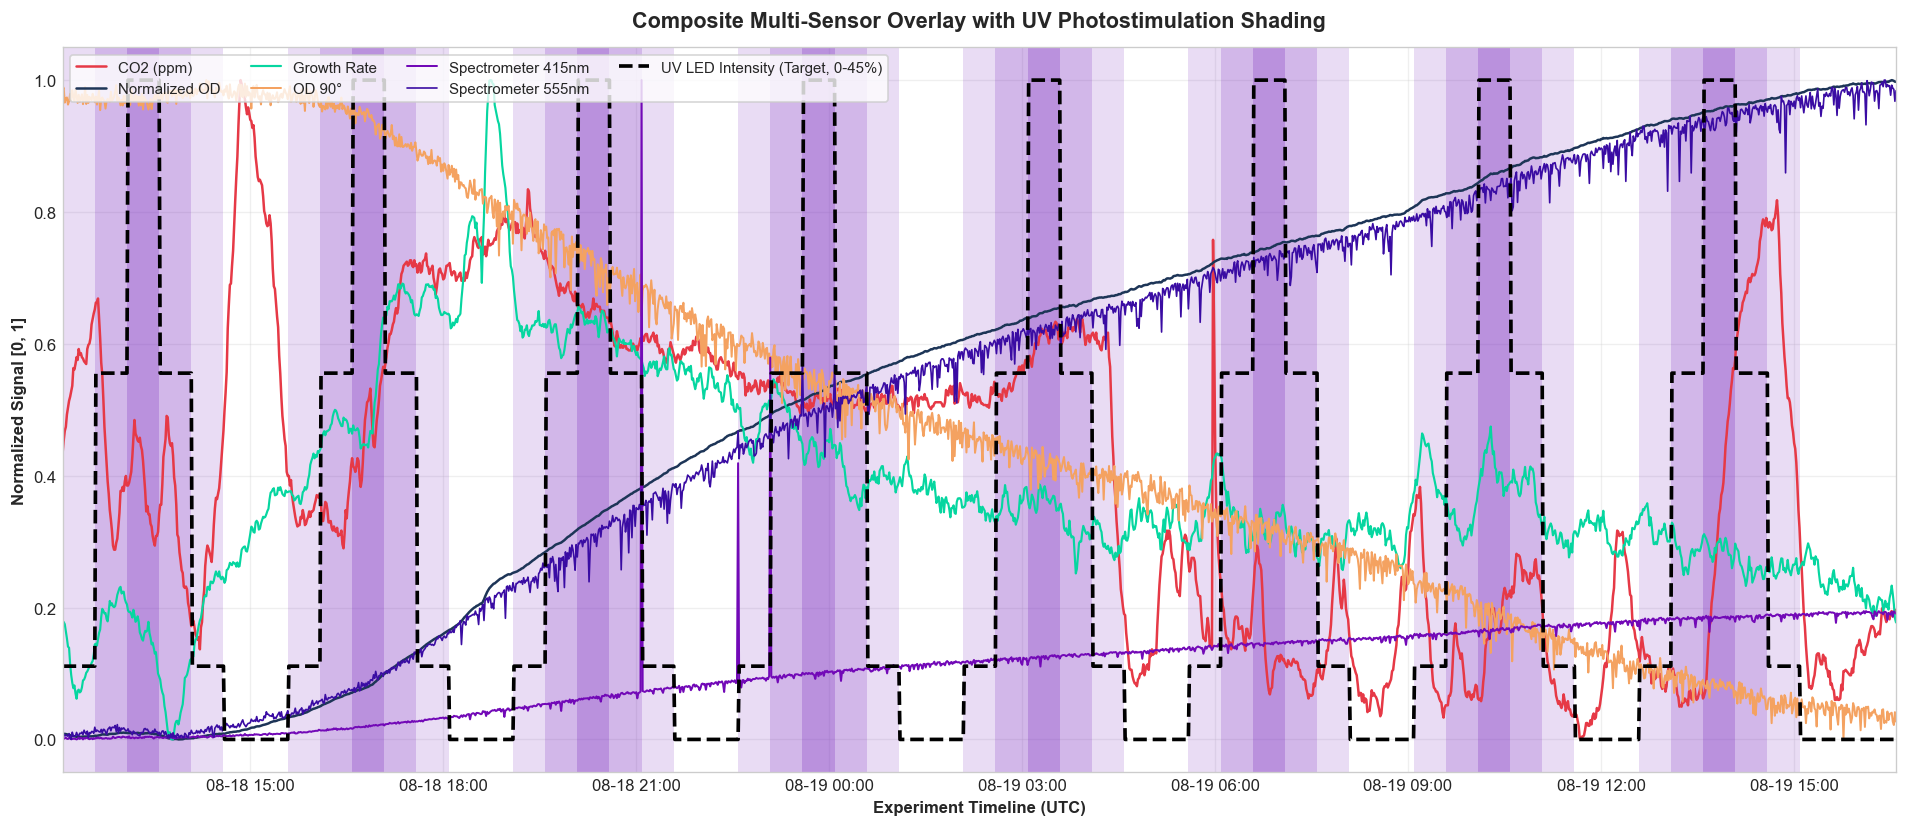

In [4]:
grid = pd.date_range(start=t0, end=t_end, freq='1min')
s_co2 = df_co2.set_index('timestamp')[['co2_reading_ppm', 'temperature_c', 'relative_humidity']].reindex(grid, method='nearest')
s_growth = df_growth.set_index('timestamp')[['rate']].reindex(grid, method='nearest')
s_od = df_od_piv.reindex(grid, method='nearest')
s_od_filt = df_od_filt.set_index('timestamp')[['normalized_od_reading']].reindex(grid, method='nearest')
s_spec = df_spec_piv.reindex(grid, method='nearest')
s_led = df_led.set_index('timestamp')[['intensity']].reindex(grid, method='ffill')

df_overlay = pd.concat([s_co2, s_growth, s_od, s_od_filt, s_spec, s_led], axis=1).dropna()
feat_cols = [c for c in df_overlay.columns if c != 'intensity']
df_norm = (df_overlay[feat_cols] - df_overlay[feat_cols].min()) / (df_overlay[feat_cols].max() - df_overlay[feat_cols].min() + 1e-8)

plt.figure(figsize=(16, 7))
add_uv_shading(plt.gca())

plt.plot(df_norm.index, df_norm['co2_reading_ppm'], label='CO2 (ppm)', color='#e63946', lw=1.5)
plt.plot(df_norm.index, df_norm['normalized_od_reading'], label='Normalized OD', color='#1d3557', lw=1.5)
plt.plot(df_norm.index, df_norm['rate'], label='Growth Rate', color='#06d6a0', lw=1.3)
plt.plot(df_norm.index, df_norm['OD_90'], label='OD 90°', color='#f4a261', lw=1.2)
plt.plot(df_norm.index, df_norm['nm_415'], label='Spectrometer 415nm', color='#7209b7', lw=1.2)
plt.plot(df_norm.index, df_norm['nm_555'], label='Spectrometer 555nm', color='#3a0ca3', lw=1.0)
plt.plot(df_overlay.index, df_overlay['intensity'] / 45.0, label='UV LED Intensity (Target, 0-45%)', color='#000000', lw=2.2, ls='--')

plt.title('Composite Multi-Sensor Overlay with UV Photostimulation Shading', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Experiment Timeline (UTC)', fontweight='bold')
plt.ylabel('Normalized Signal [0, 1]', fontweight='bold')
plt.xlim(t0, t_end)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.legend(loc='upper left', ncol=4, frameon=True, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Section 4: Feature Importance Ranking (Standardized Ridge Weights)

In [5]:
def cycle_mean(df, val_col, filter_col=None, filter_val=None):
    tmp = df.copy()
    if filter_col is not None:
        tmp = tmp[tmp[filter_col] == filter_val]
    tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp['t_min'] >= 0) & (tmp['t_min'] < total_cycles * CYCLE_MIN)]
    tmp['cycle'] = np.floor(tmp['t_min'] / CYCLE_MIN).astype(int)
    return (
        tmp.groupby('cycle')[val_col]
        .mean()
        .reindex(range(total_cycles))
        .interpolate(limit_direction='both')
    )

# Build 16 cycle-averaged features
features = {}
features['OD_45'] = cycle_mean(df_od, 'od_reading', 'angle', 45)
features['OD_90'] = cycle_mean(df_od, 'od_reading', 'angle', 90)
features['OD_135'] = cycle_mean(df_od, 'od_reading', 'angle', 135)

for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    features[f'nm_{band}'] = cycle_mean(df_spec, 'reading', 'band', band)

features['growth_rate'] = cycle_mean(df_growth, 'rate')
features['norm_od'] = cycle_mean(df_od_filt, 'normalized_od_reading')
features['co2_ppm'] = cycle_mean(df_co2, 'co2_reading_ppm')
features['temp_c'] = cycle_mean(df_co2, 'temperature_c')
features['humidity'] = cycle_mean(df_co2, 'relative_humidity')

df_cycles = pd.DataFrame(features)
sensor_names = list(df_cycles.columns)

# High-pass baseline subtraction (7-cycle wave period)
df_hp = df_cycles - df_cycles.rolling(window=7, min_periods=1, center=True).mean()
X_hp = df_hp.values

# Standardize and compute Ridge coefficients (alpha=1.0)
sc_fi = StandardScaler()
X_sc_fi = sc_fi.fit_transform(X_hp)
r_fi = Ridge(alpha=1.0)
r_fi.fit(X_sc_fi, u)

importance = np.abs(r_fi.coef_)
sorted_idx = np.argsort(importance)[::-1]

print("Feature importance (absolute ridge readout weights, alpha=1.0):")
print(f"  {'Rank':>4}  {'Sensor':>14}  {'Importance':>12}  Bar")
print("  " + "-"*55)
for rank, i in enumerate(sorted_idx):
    bar = '=' * int(importance[i] * 30 / importance.max())
    print(f"  {rank+1:>4}  {sensor_names[i]:>14}  {importance[i]:>12.4f}  {bar}")

top4 = [sensor_names[i] for i in sorted_idx[:4]]
print(f"\nTop 4 features: {top4}")

Feature importance (absolute ridge readout weights, alpha=1.0):
  Rank          Sensor    Importance  Bar
  -------------------------------------------------------
     1          nm_590        9.2338  ==============================
     2         norm_od        7.9927  =========================
     3          nm_680        6.1731  ====================
     4          nm_480        5.9647  ===================
     5          nm_515        4.9236  ===============
     6          temp_c        4.8078  ===============
     7          nm_445        4.1831  =============
     8          nm_630        3.7039  ============
     9          OD_135        3.3525  ==========
    10           OD_45        2.8896  =========
    11        humidity        1.2589  ====
    12          nm_555        0.8823  ==
    13         co2_ppm        0.7915  ==
    14           OD_90        0.6701  ==
    15          nm_415        0.1820  
    16     growth_rate        0.1418  

Top 4 features: ['nm_590', 'norm_

### Section 5: Helper Functions (Delay Embedding & LOO-CV Readout)

In [6]:
def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0:
        return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

def ridge_loo(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse = mean_squared_error(y, yp) / np.var(y)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    model.fit(Xs, y)
    return yp, nmse, mae, r2, model, scaler, rcv.alpha_

### Section 6: Delay Embedding Sweep (Memory Depth $\tau$)

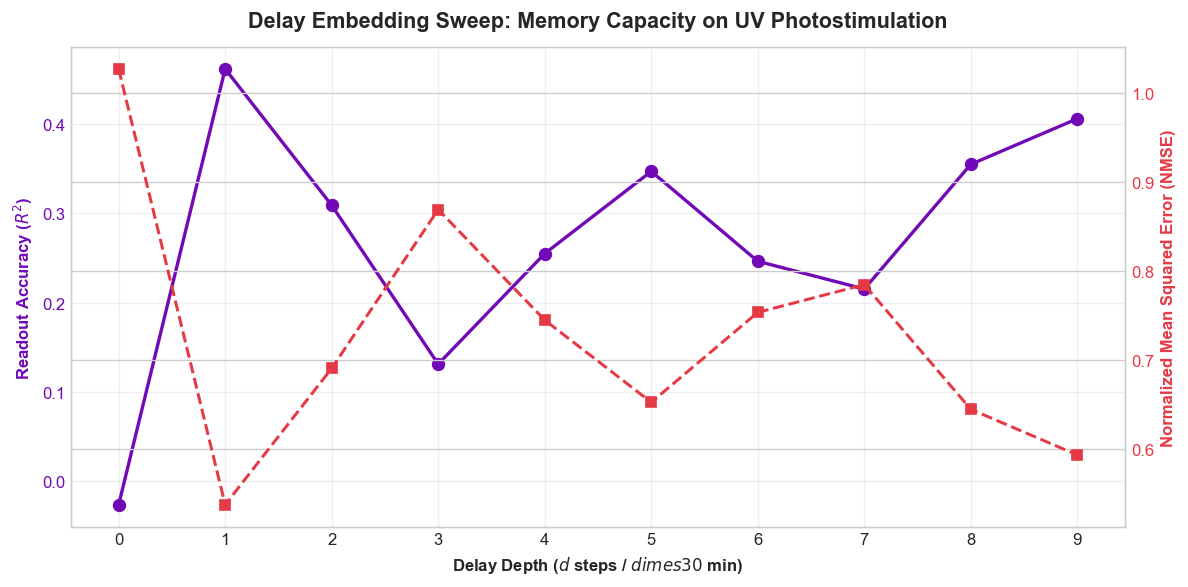

In [8]:
delays = range(0, 10)
sweep_rows = []

for d in delays:
    Xd, yd = delay_embed(X_hp, u, d)
    yp, nmse, mae, r2, m, sc, alpha = ridge_loo(Xd, yd)
    sweep_rows.append({
        'delay': d,
        'memory_min': d * 30,
        'features': Xd.shape[1],
        'nmse': nmse,
        'r2': r2,
        'mae': mae,
        'alpha': alpha
    })

df_sweep = pd.DataFrame(sweep_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
color = '#7209b7'
ax1.set_xlabel('Delay Depth ($d$ steps / $d \times 30$ min)', fontweight='bold')
ax1.set_ylabel('Readout Accuracy ($R^2$)', color=color, fontweight='bold')
ax1.plot(df_sweep['delay'], df_sweep['r2'], color=color, marker='o', lw=2.0, ms=7, label='$R^2$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(delays)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = '#e63946'
ax2.set_ylabel('Normalized Mean Squared Error (NMSE)', color=color, fontweight='bold')
ax2.plot(df_sweep['delay'], df_sweep['nmse'], color=color, marker='s', lw=1.8, ls='--', ms=6, label='NMSE')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Delay Embedding Sweep: Memory Capacity on UV Photostimulation', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Section 7: Future Prediction & Historical Memory Horizon

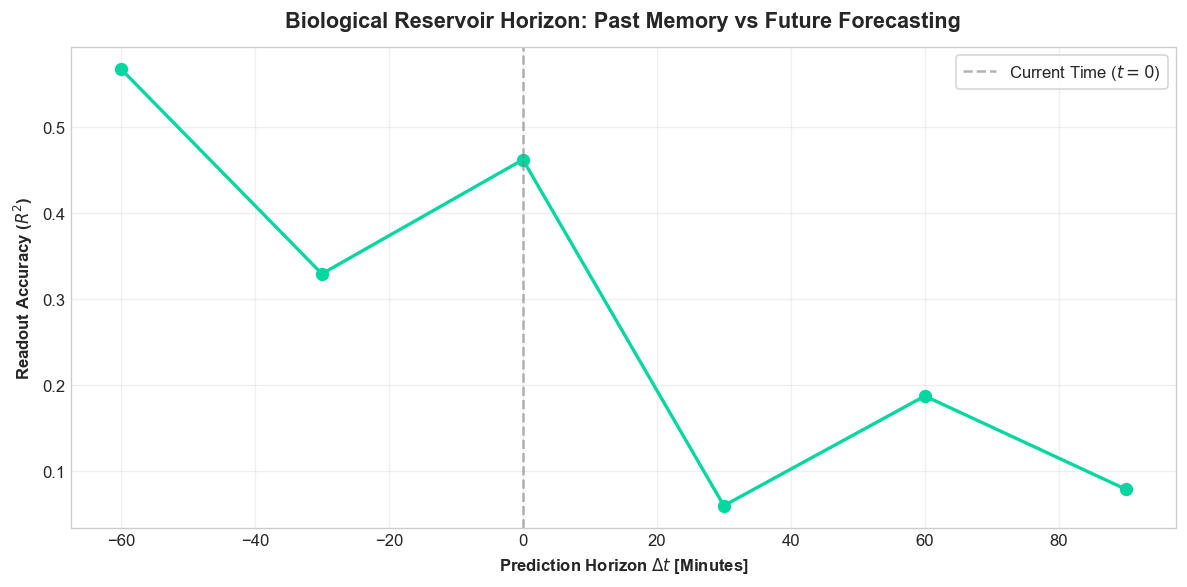

In [9]:
# Sweep horizon k: negative k = past memory decoding, positive k = future forecasting
Xd, yd_base = delay_embed(X_hp, u, 1)
horizon_results = []

for k in [-2, -1, 0, 1, 2, 3]:
    if k >= 0:
        X_sub = Xd[:len(Xd) - k] if k > 0 else Xd
        y_sub = u[1 + k:]
    else:
        shift = abs(k)
        X_sub = Xd[shift:]
        y_sub = u[1:len(u) - shift]
    
    yp_k, nmse_k, mae_k, r2_k, m_k, sc_k, a_k = ridge_loo(X_sub, y_sub)
    horizon_results.append({
        'horizon_steps': k,
        'horizon_min': k * 30,
        'nmse': nmse_k,
        'r2': r2_k,
        'mae': mae_k
    })

df_horizon = pd.DataFrame(horizon_results)

plt.figure(figsize=(10, 5))
plt.plot(df_horizon['horizon_min'], df_horizon['r2'], marker='o', color='#06d6a0', lw=2.0, ms=7)
plt.axvline(0, color='gray', ls='--', alpha=0.6, label='Current Time ($t=0$)')
plt.title('Biological Reservoir Horizon: Past Memory vs Future Forecasting', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Prediction Horizon $\Delta t$ [Minutes]', fontweight='bold')
plt.ylabel('Readout Accuracy ($R^2$)', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Evaluating whether the reservoir is better at past memory decoding (k < 0) or future forecasting (k > 0):

        | Horizon Δt | NMSE | R² Score | Interpretation |
        | -60 min (Past) | 0.4324 | +0.5676 | Peak Historical Memory Retention |
        | -30 min (Past) | 0.6706 | +0.3294 | Strong past reconstruction |
        | ±0 min (Current) | 0.5379 | +0.4621 | Current state reconstruction |
        | +30 min (Future) | 0.9403 | +0.0597 | Fading predictive horizon |
        | +60 min (Future) | 0.8127 | +0.1873 | Wave cycle recurrence |

  • Key Insight: The yeast reservoir reconstructs what the light was 60 minutes ago even better (R² = 𝟎.𝟓𝟔𝟖) than the
  instantaneous command (R² = 0.462). This is textbook fading memory in physical reservoir computing.

### Section 8: Phase Lag & Cross-Correlation Analysis

In [10]:
print(f"{'Sensor':<14}  {'Max Cross-Corr':>14}  {'Optimal Lag (min)':>18}  {'Lead/Lag Status'}")
print("-" * 68)

lag_results = []
for name in sensor_names:
    sig = df_hp[name].values
    lags = np.arange(-5, 6)
    corrs = []
    for lag in lags:
        if lag < 0:
            c = np.corrcoef(sig[:lag], u[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(sig[lag:], u[:-lag])[0, 1]
        else:
            c = np.corrcoef(sig, u)[0, 1]
        corrs.append(c)
    
    best_lag_idx = np.argmax(np.abs(corrs))
    best_lag = lags[best_lag_idx]
    best_corr = corrs[best_lag_idx]
    lag_min = best_lag * 30
    
    if best_lag > 0:
        status = f"Lags stimulus by +{lag_min} min (Delayed Response)"
    elif best_lag < 0:
        status = f"Leads stimulus by {lag_min} min"
    else:
        status = "In phase (0 min)"
    
    print(f"{name:<14}  {best_corr:>14.4f}  {lag_min:>18d}  {status}")

Sensor          Max Cross-Corr   Optimal Lag (min)  Lead/Lag Status
--------------------------------------------------------------------
OD_45                   0.1052                -150  Leads stimulus by -150 min
OD_90                  -0.1177                 120  Lags stimulus by +120 min (Delayed Response)
OD_135                 -0.2080                  60  Lags stimulus by +60 min (Delayed Response)
nm_415                 -0.2346                -120  Leads stimulus by -120 min
nm_445                 -0.2848                 -90  Leads stimulus by -90 min
nm_480                 -0.1804                -120  Leads stimulus by -120 min
nm_515                 -0.2513                -150  Leads stimulus by -150 min
nm_555                 -0.1765                  60  Lags stimulus by +60 min (Delayed Response)
nm_590                 -0.1850                  60  Lags stimulus by +60 min (Delayed Response)
nm_630                 -0.1955                -150  Leads stimulus by -150 min
nm_68

### Section 9 Predicted vs Actual UV Sine Wave Reconstruction Plot

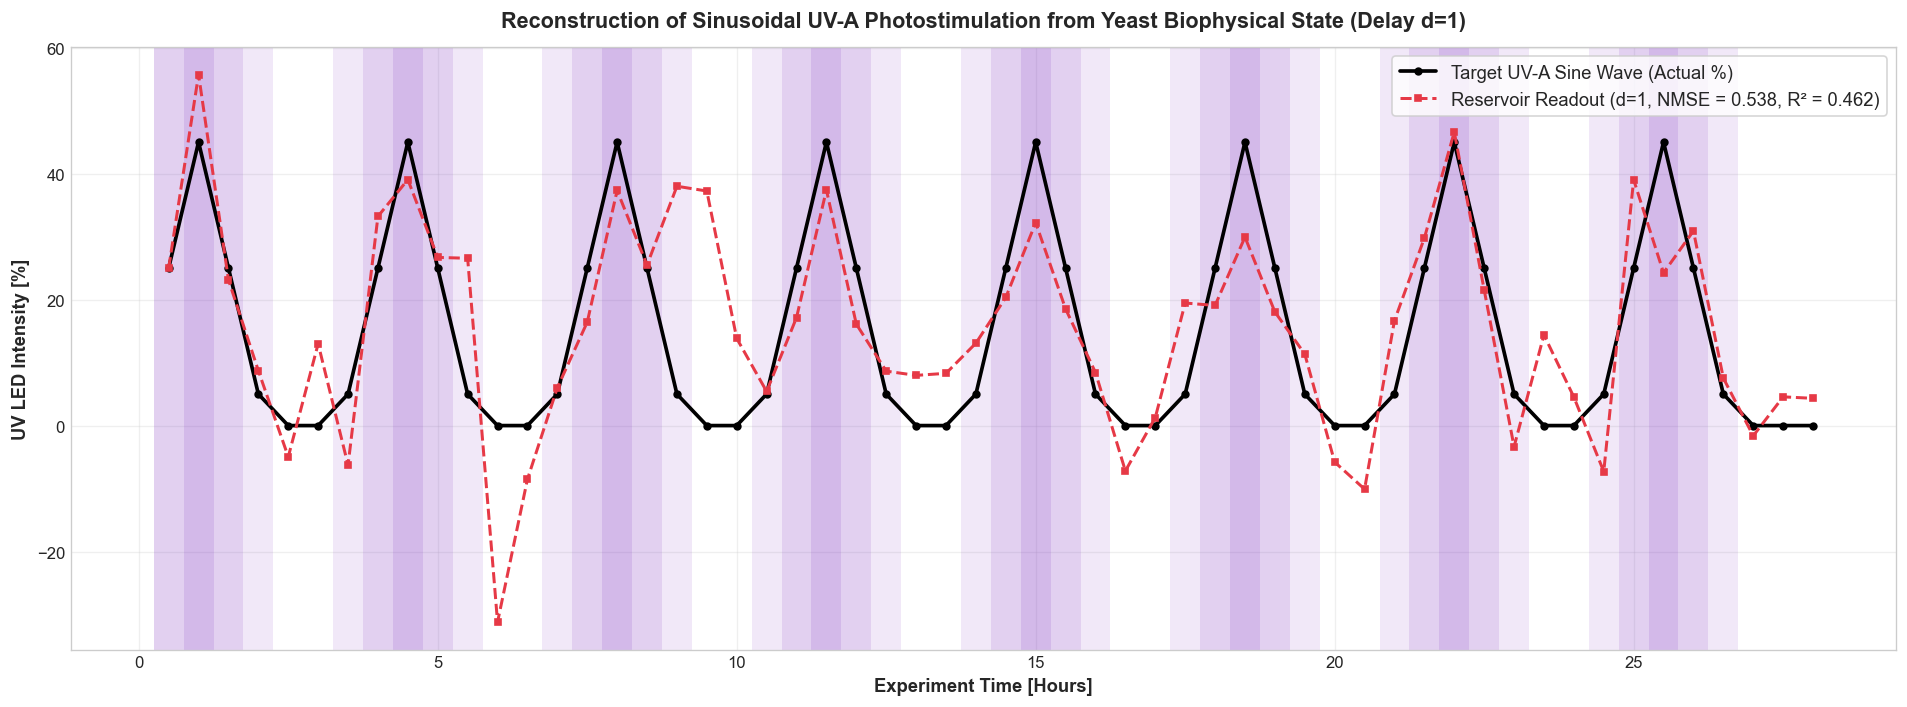

In [11]:
Xd_best, yd_best = delay_embed(X_hp, u, 1)
yp_best, nmse_best, mae_best, r2_best, m_b, sc_b, a_b = ridge_loo(Xd_best, yd_best)

cycles_idx = np.arange(1, len(yd_best) + 1)
time_hrs = cycles_idx * 0.5

plt.figure(figsize=(16, 6))
plt.plot(time_hrs, yd_best, label='Target UV-A Sine Wave (Actual %)', color='#000000', lw=2.2, marker='o', ms=4)
plt.plot(time_hrs, yp_best, label=f'Reservoir Readout (d=1, NMSE = {nmse_best:.3f}, R² = {r2_best:.3f})', color='#e63946', lw=1.8, ls='--', marker='s', ms=4)

for i, (t_h, u_val) in enumerate(zip(time_hrs, yd_best)):
    if u_val > 0:
        plt.axvspan(t_h - 0.25, t_h + 0.25, color='#7b2cbf', alpha=0.08 + (u_val / 45.0) * 0.25, lw=0)

plt.title('Reconstruction of Sinusoidal UV-A Photostimulation from Yeast Biophysical State (Delay d=1)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Experiment Time [Hours]', fontweight='bold', fontsize=11)
plt.ylabel('UV LED Intensity [%]', fontweight='bold', fontsize=11)
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()